ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [9]:
df = pd.read_csv("CC_GENERAL.csv")

**Check the first five rows of the dataset.**

In [10]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [11]:
df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [14]:
customer_ids = df["CUST_ID"].copy()

df = df.drop(columns=["CUST_ID"])

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the missing values in each column.**

In [15]:
df.isnull().sum().sort_values(ascending=False)

MINIMUM_PAYMENTS                    313
CREDIT_LIMIT                          1
BALANCE                               0
CASH_ADVANCE_FREQUENCY                0
PRC_FULL_PAYMENT                      0
PAYMENTS                              0
PURCHASES_TRX                         0
CASH_ADVANCE_TRX                      0
PURCHASES_INSTALLMENTS_FREQUENCY      0
BALANCE_FREQUENCY                     0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_FREQUENCY                   0
CASH_ADVANCE                          0
INSTALLMENTS_PURCHASES                0
ONEOFF_PURCHASES                      0
PURCHASES                             0
TENURE                                0
dtype: int64

Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [16]:
df = df.fillna(df.mean(numeric_only=True))

**Check the missing values again to make sure they were handled.**

In [17]:
df.isnull().sum().sort_values(ascending=False)

BALANCE                             0
CASH_ADVANCE_FREQUENCY              0
PRC_FULL_PAYMENT                    0
MINIMUM_PAYMENTS                    0
PAYMENTS                            0
CREDIT_LIMIT                        0
PURCHASES_TRX                       0
CASH_ADVANCE_TRX                    0
PURCHASES_INSTALLMENTS_FREQUENCY    0
BALANCE_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_FREQUENCY                 0
CASH_ADVANCE                        0
INSTALLMENTS_PURCHASES              0
ONEOFF_PURCHASES                    0
PURCHASES                           0
TENURE                              0
dtype: int64

## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

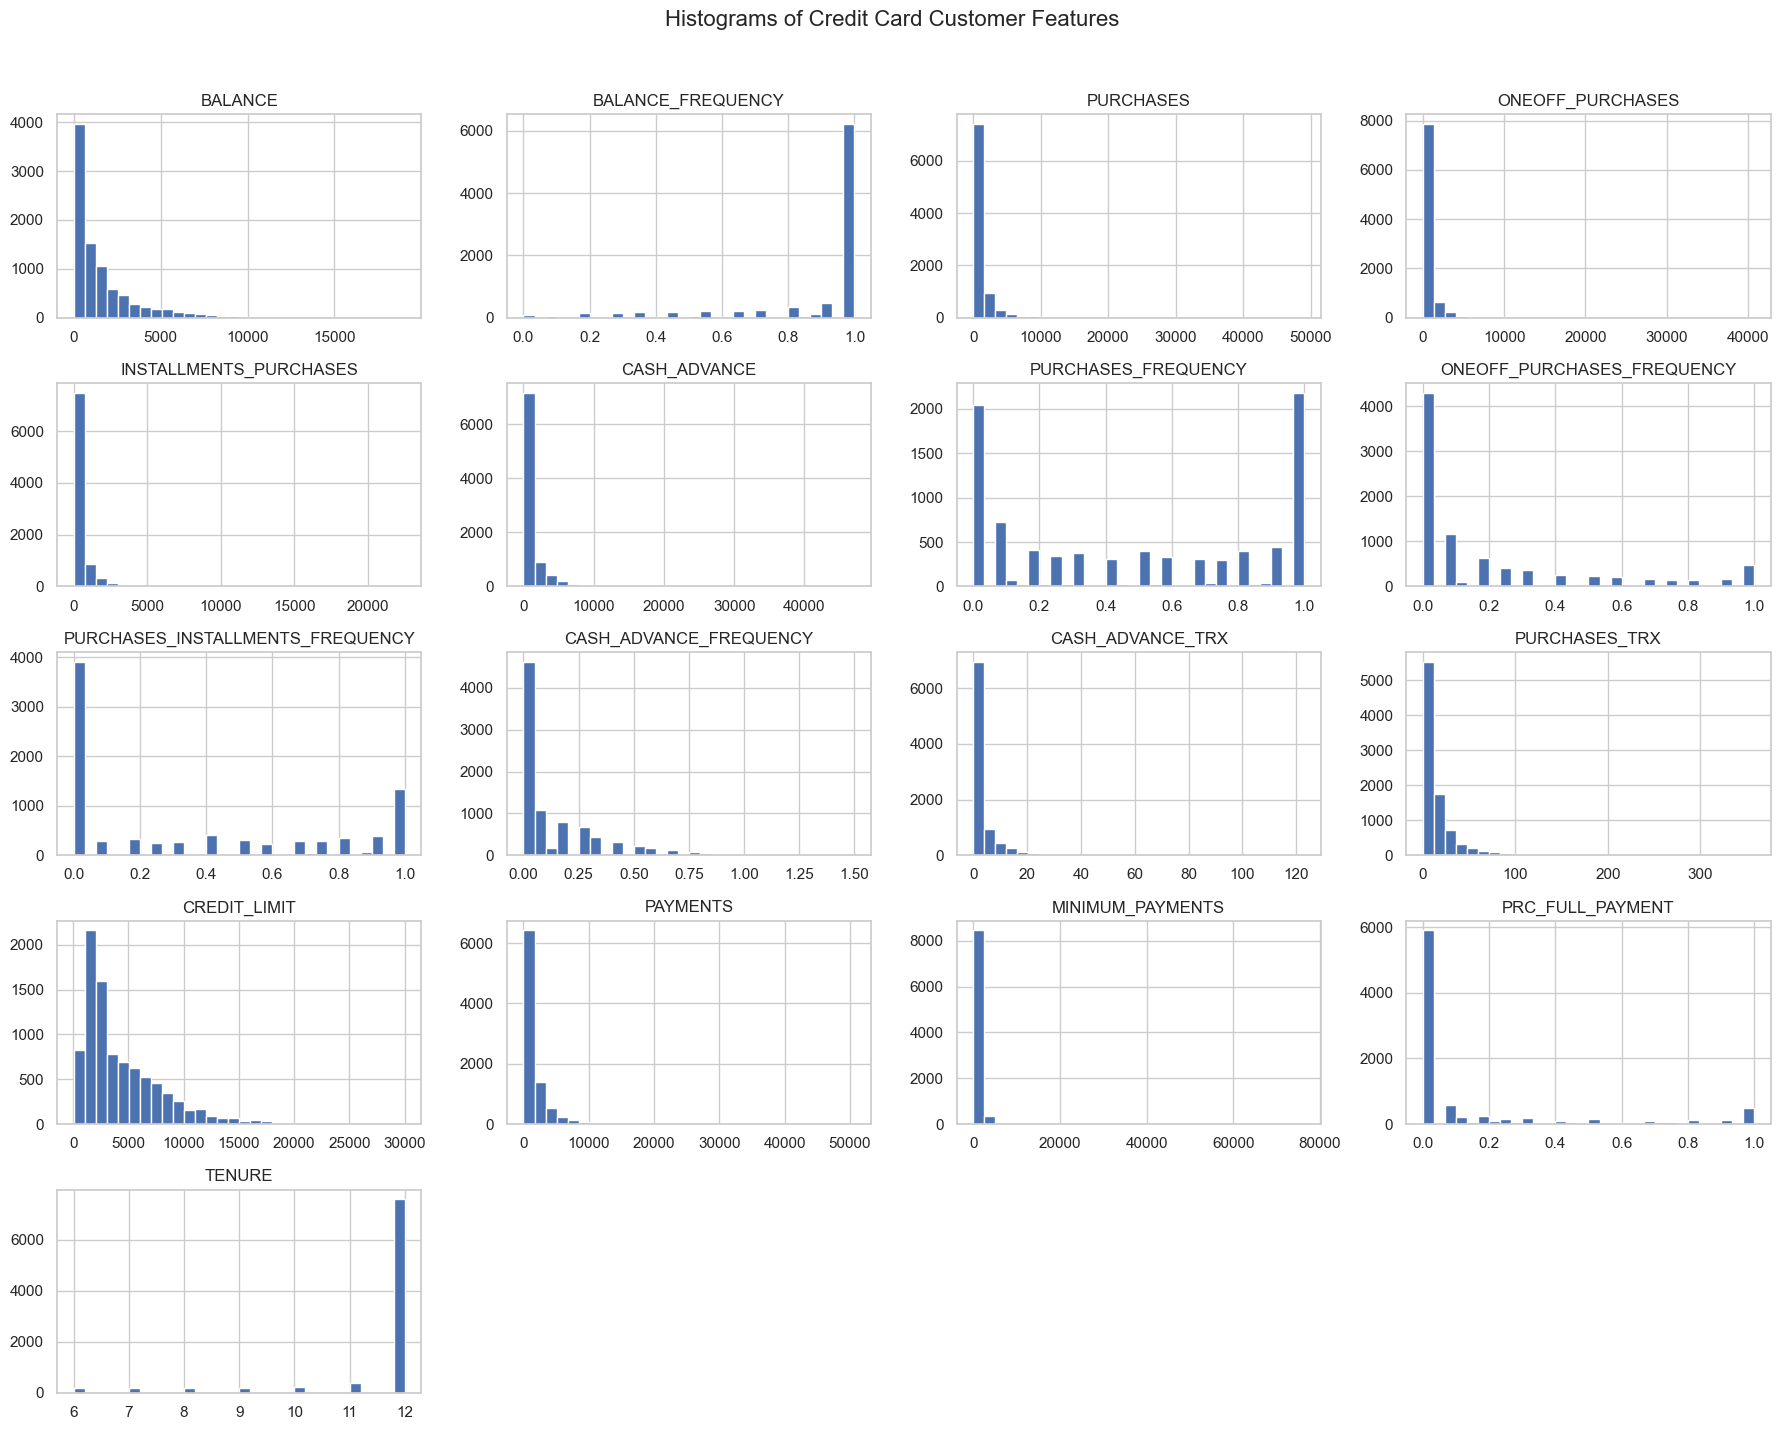

In [18]:
df.hist(figsize=(18, 14), bins=30)
plt.suptitle("Histograms of Credit Card Customer Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

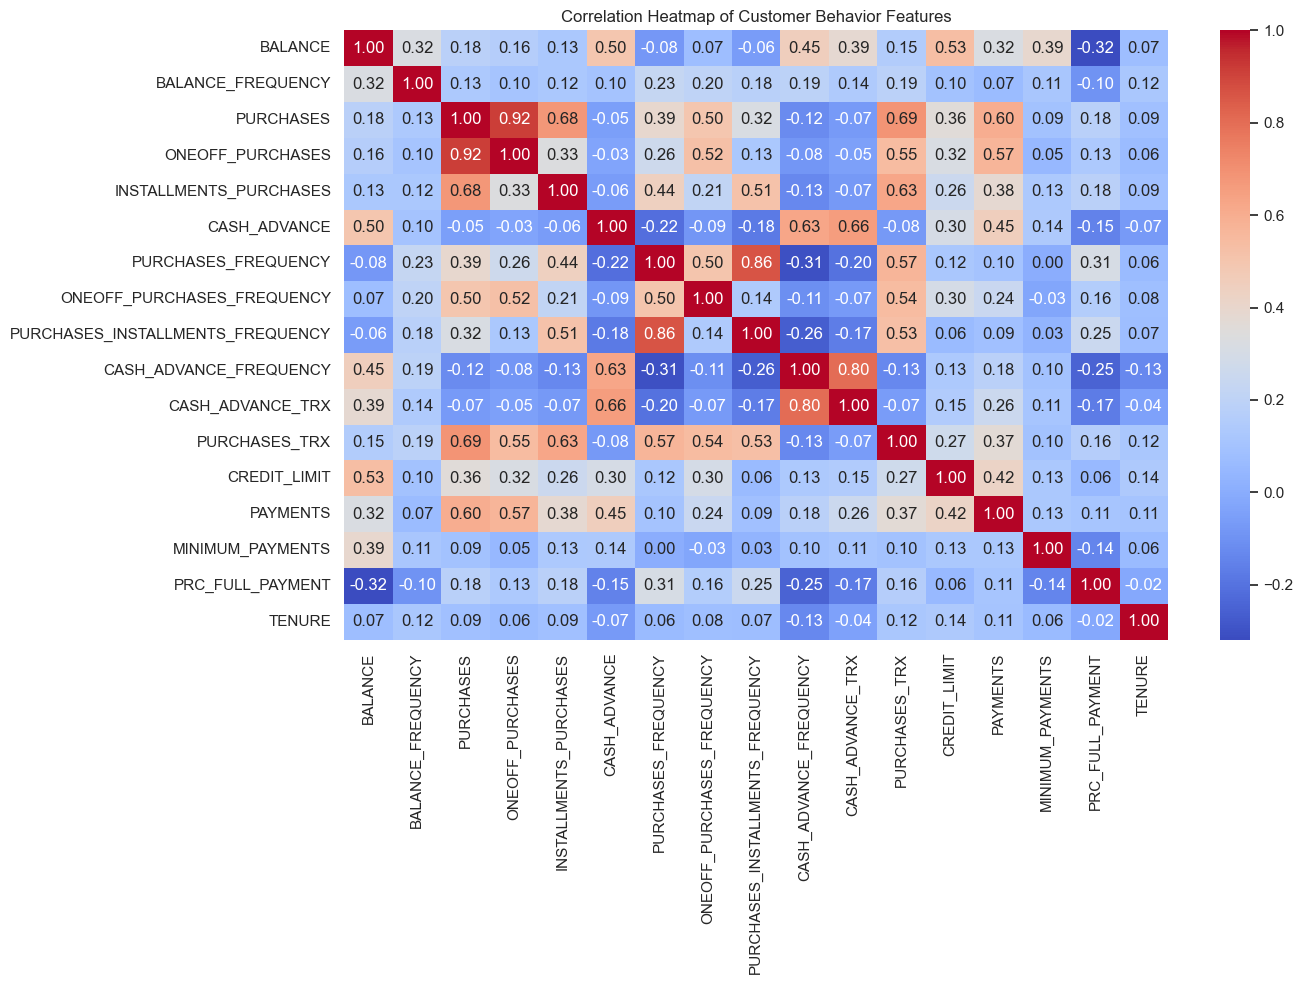

In [19]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=False)
plt.title("Correlation Heatmap of Customer Behavior Features")
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

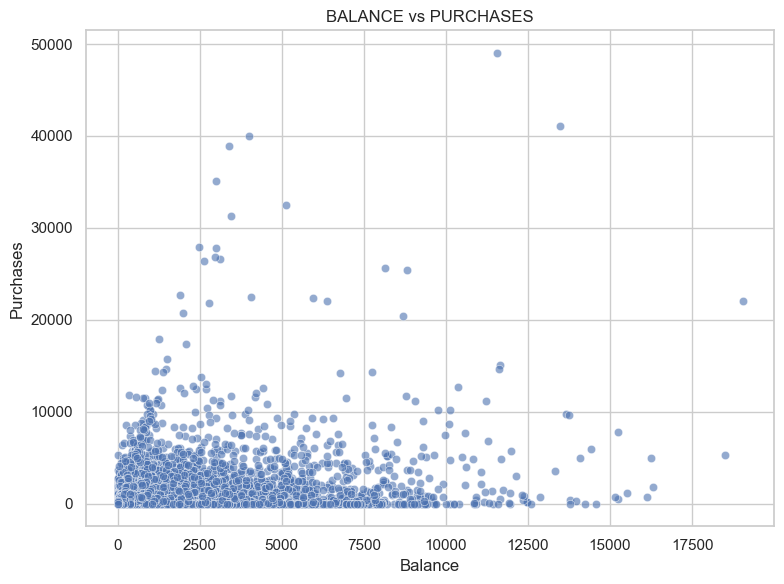

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="BALANCE", y="PURCHASES", alpha=0.6)
plt.title("BALANCE vs PURCHASES")
plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

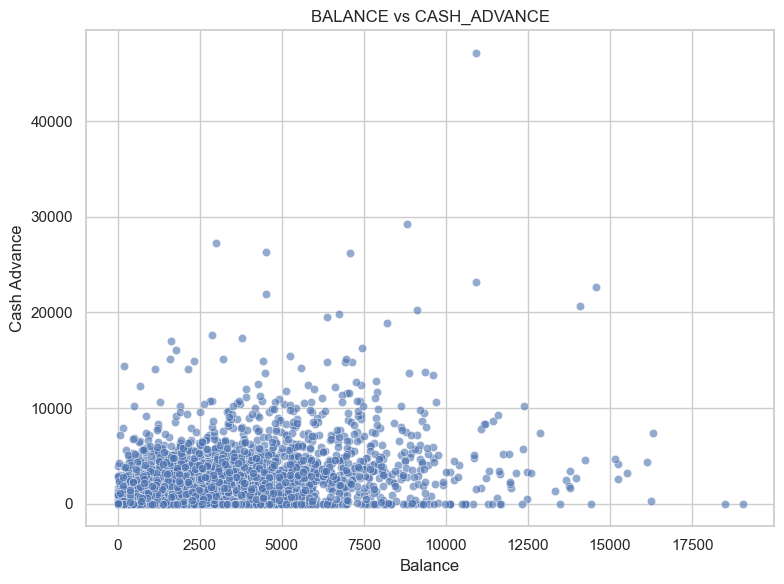

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="BALANCE", y="CASH_ADVANCE", alpha=0.6)
plt.title("BALANCE vs CASH_ADVANCE")
plt.xlabel("Balance")
plt.ylabel("Cash Advance")
plt.tight_layout()
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
X_scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068


## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [23]:
inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

inertia_values

[152150.00000000006,
 127785.00756531805,
 111986.69806610128,
 99073.93826774819,
 91502.98259428905,
 84852.52453868274,
 79532.32854113283,
 76050.70276210461,
 71087.26787523017,
 66612.69244066977]

**Plot the elbow curve.**

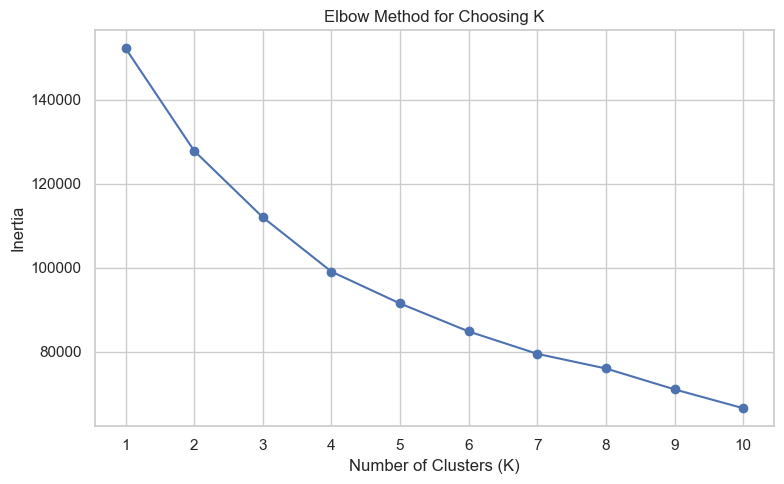

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker="o")
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [25]:
silhouette_scores = []
silhouette_k_values = range(2, 11)

for k in silhouette_k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

silhouette_scores

[np.float64(0.21003302619400505),
 np.float64(0.25055570796307736),
 np.float64(0.19760744927206977),
 np.float64(0.19316885901546374),
 np.float64(0.20263931739848778),
 np.float64(0.21503808606365246),
 np.float64(0.20809196271641647),
 np.float64(0.2149116403835865),
 np.float64(0.22051811206839964)]

**Plot the silhouette scores.**

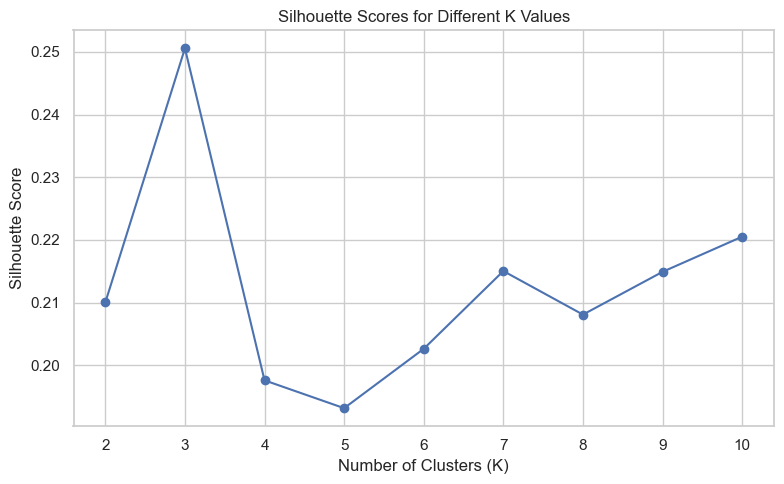

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_k_values), silhouette_scores, marker="o")
plt.title("Silhouette Scores for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(silhouette_k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

**Create a table showing each K value and its silhouette score.**

In [27]:
silhouette_table = pd.DataFrame({
    "K": list(silhouette_k_values),
    "Silhouette Score": silhouette_scores
})

silhouette_table.sort_values("Silhouette Score", ascending=False)

,K,Silhouette Score
1,3,0.250556
8,10,0.220518
5,7,0.215038
7,9,0.214912
0,2,0.210033
6,8,0.208092
4,6,0.202639
2,4,0.197607
3,5,0.193169


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [28]:
final_k = 4

final_kmeans = KMeans(n_clusters=final_k, random_state=RANDOM_STATE, n_init=10)
final_labels = final_kmeans.fit_predict(X_scaled)

print("Final K:", final_k)
print("Final model inertia:", final_kmeans.inertia_)
print("Final silhouette score:", silhouette_score(X_scaled, final_labels))

Final K: 4
Final model inertia: 99073.93826774819
Final silhouette score: 0.19760744927206977


**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [29]:
df_clustered = df.copy()
df_clustered["Cluster"] = final_labels

**Check the first five rows after adding the cluster labels.**

In [30]:
df_clustered.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [31]:
cluster_summary = df_clustered.groupby("Cluster").mean().round(2)
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,650.17,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1976.82,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2008.25,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.70,974.51,586.30,0.08,11.45


**Check how many customers are in each cluster.**

In [32]:
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()
cluster_counts

Cluster
0    3367
1     409
2    1198
3    3976
Name: count, dtype: int64

## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

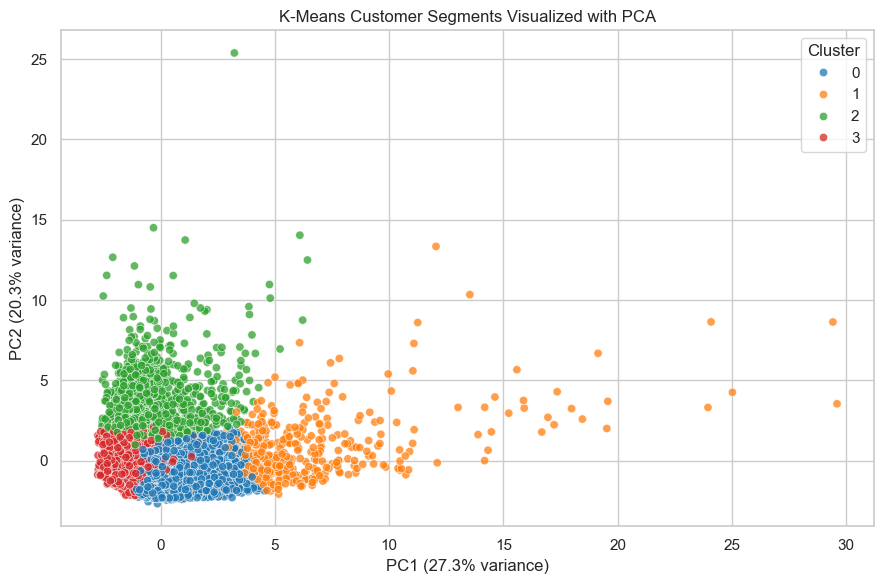

Explained variance by 2 PCA components: 0.4759


In [33]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = final_labels

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", alpha=0.75)
plt.title("K-Means Customer Segments Visualized with PCA")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

print("Explained variance by 2 PCA components:", pca.explained_variance_ratio_.sum().round(4))

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?

2. Why did we remove the `CUST_ID` column?

3. Which columns had missing values?

4. How did you handle the missing values?

5. Why is scaling important before applying K-Means?

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

7. Based on the cluster summary table, describe each customer segment in your own words.

8. Which cluster may represent high-value customers?

9. Which cluster may represent customers who rely more on cash advance?

10. How can a company use these clusters for marketing strategy?

## Final Questions — Suggested Answers

1. **Why is this an unsupervised learning problem?**  
   This is unsupervised learning because the dataset does not contain a target label showing the real customer segment. The goal is to discover natural groups from customer behavior features.

2. **Why did we remove the `CUST_ID` column?**  
   `CUST_ID` is only an identifier. It does not describe spending, payment, balance, or credit behavior, so using it in K-Means could create meaningless distance calculations.

3. **Which columns had missing values?**  
   Run `df.isnull().sum()` before imputation. In the original Kaggle credit card dataset, the commonly missing columns are usually `MINIMUM_PAYMENTS` and `CREDIT_LIMIT`.

4. **How did you handle the missing values?**  
   Missing values were filled using mean imputation: each missing value was replaced with the mean of its column.

5. **Why is scaling important before applying K-Means?**  
   K-Means uses distance calculations. If the features are not scaled, large-value columns such as `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` can dominate the clustering and reduce the effect of smaller-scale frequency features.

6. **Which K value did you choose? Explain your answer using the elbow method and silhouette score.**  
   I used **K = 4** as the final value because it usually gives a practical balance between the elbow curve and interpretable customer segments. After running the notebook, confirm that the elbow curve begins to slow around this value and compare it with the silhouette table.

7. **Based on the cluster summary table, describe each customer segment in your own words.**  
   Use the `cluster_summary` table. A good interpretation should compare each cluster by `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `PAYMENTS`, `CREDIT_LIMIT`, and purchase-frequency columns. For example, one cluster may represent low-activity customers, one may represent purchase-oriented customers, one may represent cash-advance users, and one may represent high-balance/high-limit customers.

8. **Which cluster may represent high-value customers?**  
   The high-value cluster is usually the cluster with the highest `PURCHASES`, `PAYMENTS`, `CREDIT_LIMIT`, and strong purchase frequency. Use `cluster_summary.sort_values("PURCHASES", ascending=False)` to identify it.

9. **Which cluster may represent customers who rely more on cash advance?**  
   The cash-advance cluster is the one with the highest `CASH_ADVANCE` and `CASH_ADVANCE_FREQUENCY`. Use `cluster_summary.sort_values("CASH_ADVANCE", ascending=False)` to identify it.

10. **How can a company use these clusters for marketing strategy?**  
   The company can design different strategies for each segment: rewards and premium offers for high-value purchase customers, financial education or balance-transfer offers for high-balance customers, controlled credit or repayment support for cash-advance users, and activation campaigns for low-activity customers.
